In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.7.12


In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path

from cmdstanpy import CmdStanModel
from culRIBayesian.stan_utils import *
import culRIBayesian.dataviz_utils as dv

import bayspline as bsl
import bayspar as bsr



In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(66.6667,-18.6667),
        'schouteN_meso003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(0.015,0.280),
        'schouteN_meso003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [7]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/culRIBayesian/stan_models/'

## Ensure a freshly compiled stan files

In [8]:
def refresh_stan_models():
    """
    This function compiles the Stan models in the specified directory.
    It removes any existing binaries and recompiles the models.
    """
    print("Compiling Stan models...")
    import subprocess
    from pathlib import Path

    # Define the Stan models directory
    stan_dir = Path(stan_models_path)

    # Optional: Clean previous builds to avoid stale artifacts
    print("Cleaning previous Stan builds...")
    subprocess.run(["make", "clean"], cwd=stan_dir)

    # Find all .stan files in the directory
    stan_files = list(stan_dir.glob("*.stan"))

    # Recompile each Stan model
    for stan_file in stan_files:
        binary_file = stan_file.with_suffix("")  # e.g., model.stan -> model (executable)
        
        # Remove the existing binary to avoid GLIBC or libstdc++ mismatches
        if binary_file.exists():
            print(f"Removing old binary: {binary_file.name}")
            binary_file.unlink()
        
        # Compile the Stan model
        print(f"Compiling: {stan_file.name}")
        result = subprocess.run(["make", binary_file.name], cwd=stan_dir)
        
        if result.returncode != 0:
            print(f"❌ Compilation failed for {stan_file.name}")
        else:
            print(f"✅ Successfully compiled {binary_file.name}")

    print("Stan models compiled successfully.")



refresh_stan_models()


Compiling Stan models...
Cleaning previous Stan builds...
Compiling: jnt_cul_meso_hier_crtp_multiv.stan
❌ Compilation failed for jnt_cul_meso_hier_crtp_multiv.stan
Compiling: jnt_cul_meso_hier_crtp_archive.stan
❌ Compilation failed for jnt_cul_meso_hier_crtp_archive.stan
Compiling: jnt_cul_meso_hier_crtp_multiv_archive.stan
❌ Compilation failed for jnt_cul_meso_hier_crtp_multiv_archive.stan
Compiling: jnt_cul_meso_hier_crtp.stan
❌ Compilation failed for jnt_cul_meso_hier_crtp.stan
Removing old binary: hier_crtp_univ_prior_logmixture
Compiling: hier_crtp_univ_prior_logmixture.stan
❌ Compilation failed for hier_crtp_univ_prior_logmixture.stan
Removing old binary: hier_crtp_univ_prior_approx
Compiling: hier_crtp_univ_prior_approx.stan
❌ Compilation failed for hier_crtp_univ_prior_approx.stan
Compiling: jnt_culmeso_hier_crtp_logistic_fixed_multiv.stan
❌ Compilation failed for jnt_culmeso_hier_crtp_logistic_fixed_multiv.stan
Removing old binary: jnt_cul_meso
Compiling: jnt_cul_meso.stan
❌ C

make: *** No rule to make target 'clean'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_hier_crtp_multiv'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_hier_crtp_archive'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_hier_crtp_multiv_archive'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_hier_crtp'.  Stop.
make: *** No rule to make target 'hier_crtp_univ_prior_logmixture'.  Stop.
make: *** No rule to make target 'hier_crtp_univ_prior_approx'.  Stop.
make: *** No rule to make target 'jnt_culmeso_hier_crtp_logistic_fixed_multiv'.  Stop.
make: *** No rule to make target 'jnt_cul_meso'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_crtp'.  Stop.
make: *** No rule to make target 'invT_logistic_fixed_univ'.  Stop.
make: *** No rule to make target 'invT_logistic_fixed_multiv'.  Stop.


In [9]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [10]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_sst = T_da.isel(depth=0).t_an
woas23_sst

<xarray.DataArray 't_an' (time: 1, lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
    depth    float32 0.0
  * time     (time) float32 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [11]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds_tmp = xr.open_dataset(os.path.join(fpath, fname))
ocean_properties_ds = xr.merge(
    [ocean_properties_ds_tmp, woas23_sst.rename('sst')],
    compat='override',
    join='override'
)
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    depth          float32 0.0
  * time           (time) float64 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                (lat: 720, lon: 1440)
Coordinates:
  * lat                    (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                    (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables: (12/14)
    region_ID              (lon, lat) float64 ...
    tex_count              (lon, lat) float64 ...
    tex_median             (lon, lat) float64 ...
    tex_mean               (lon, lat) float64 ...
    tex_std                (lon, lat) float64 ...
    scaledRI_count         (lon, lat) float64 ...
    ...                     ...
    scaledRI_std           (lon, lat) float64 ...
    gdgt23ratio_count      (lon, lat) float64 ...
    gdgt23ratio_median     (lon, lat) float64 ...
    gdgt23ratio_mean       (lon, lat) float64 ...
    gdgt23ratio_std        (lon, lat) float64 ...
    modernWaterDepth_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [12]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df = coretop_ds_merged.to_dataframe()
coretop_df = coretop_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median',
                                                             'gdgt23ratio_median',
                                                             't_sf2tc_avg']).reset_index()
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041
1461,86.625,152.125,1878.0,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,...,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909,0.0,-1.57041
1462,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180
1463,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371


In [13]:
# ─── prepare sample points ────────────────────────────────────────────────────
xx = np.linspace(-4, 50, 200)

# ─── filter & group your data ──────────────────────────────────────────────────
plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
min_count = 2
groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# ─── build the figure with one trace per strain per model ─────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=coretop_df['t_sf2tc_avg'],
    y=coretop_df['scaledRI_median'],
    mode='markers',
    marker=dict(color='rgba(178,178,178,1.000)', size=5),
    name='Core-top data',
    showlegend=True   # you can allow toggling it via legend if you like
))
core_idx = 0  # index of this core-top trace

# ─── add global fits ────────────────────────────────────────────────
X_all = plot_data['Temperature'].values.reshape(-1,1)
y_all = plot_data['scaledRI'].values

# -- Linear fit --
ols_all = LinearRegression().fit(X_all, y_all)
y_lin_all = ols_all.predict(xx.reshape(-1,1))


# -- Logistic fixed upper --
p0f = [25, 0.1, 0.1]
bf = (0, [50,1,1])
popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# -- Full logistic --
p0_all = [25,0.1,0.1,0.1]
bnd_all = (0, [50,1,1,1])
popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
y_logi_all = logistic(xx, *popt_all)
r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
    ("Logistic fixed", y_logif_all, r2_logif_all),
    ("Logistic", y_logi_all, r2_logi_all)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso -- {model} (R²={r2:.2f})",
        visible=True
    ))

### add X_all and y_all with coretop data and fit the glob_cul_meso_crtp
X_all_full = np.concatenate((coretop_df['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
y_all_full = np.concatenate((coretop_df['scaledRI_median'].values, plot_data['scaledRI'].values))

# -- Linear fit --
ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# -- Logistic fixed upper --
p0f_full = [25, 0.1, 0.1]
bf_full = (0, [50,1,1])
popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# -- Full logistic --
p0_all_full = [25,0.1,0.1,0.1]
bnd_all_full = (0, [50,1,1,1])
popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
y_logi_all_full = logistic(xx, *popt_all_full)
r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
    ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
    ("Logistic", y_logi_all_full, r2_logi_all_full)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso_crtp -- {model} (R²={r2:.2f})",
        visible=True
    ))
    
# ─── add all your strain traces ───────────────────────────
for strain in groups:
    df = plot_data[plot_data['Strains_edited'] == strain]
    X = df['Temperature'].values.reshape(-1,1)
    y = df['scaledRI'].values
    
    # -- Linear fit --
    ols = LinearRegression().fit(X, y)
    y_lin = ols.predict(xx.reshape(-1,1))
    fig.add_trace(go.Scatter(
        x=xx, y=y_lin, 
        mode='lines',
        name=f"{strain} -- Linear (R²={ols.score(X,y):.2f})",
        visible=(strain == groups[0])  # only first strain visible initially
    ))
    
    # -- Logistic fixed upper --
    p0f = [25, 0.1, 0.1]
    bf = (0, [50,1,1])
    popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
    y_logf = logistic_fixed_upper(xx, *popt_f)
    r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_logf,
        mode='lines',
        name=f"{strain} -- Logistic fixed (R²={r2_f:.2f})",
        visible=False
    ))
    
    # -- Full logistic --
    p0 = [25,0.1,0.1,0.1]
    bnd = (0, [50,1,1,1])
    popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
    y_log = logistic(xx, *popt)
    r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_log,
        mode='lines',
        name=f"{strain} -- Logistic (R²={r2:.2f})",
        visible=False
    ))
    
    # -- Always-on scatter of raw data --
    fig.add_trace(go.Scatter(
        x=df['Temperature'], y=df['scaledRI'],
        mode='markers',
        marker=dict(size=6, line=dict(width=1, color='black')),
        name=f"{strain} -- data",
        visible=True
    ))
# build a mapping strain → color
palette1 = px.colors.qualitative.Set1
palette2 = px.colors.qualitative.Set2

# make one long list
all_colors = palette1 + palette2

# then map strains in order
strain_colors = {
    strain: all_colors[i % len(all_colors)]
    for i, strain in enumerate(groups)
}

# now loop through all traces
for trace in fig.data:
    # The “cultures + mesocosm only” global fit
    if trace.name.startswith("glob_cul_meso --"):
        trace.update(line=dict(
            color="black",   # pick any CSS name or hex code
            dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
            width=4              # thicker line
        ))

    # The “cultures + mesocosm + coretop” global fit
    elif trace.name.startswith("glob_cul_meso_crtp --"):
        trace.update(line=dict(
            color="black",
            dash="dashdot",
            width=3
        ))
        
    # skip the core-top (and any other truly global or background traces)
    elif trace.name == "Core-top data":
        continue

    # split off the strain name (everything before the “ – ”)
    strain = trace.name.split(" -- ")[0]

    # pick a color: if it’s one of our strains, use its palette color;
    # otherwise (e.g. “Global”) fall back to black or whatever you like
    col = strain_colors.get(strain, "black")

    # apply to both marker & line
    trace.update(
        marker=dict(color=col),
        line=dict(color=col)
    )



# Hide all line traces (fits) by default, leave markers visible
for trace in fig.data:
    if "lines" in trace.mode:
        trace.visible = "legendonly"
    else:
        trace.visible = True

# # Make “raw data” the initial visibility state:
# for tr in fig.data:
#     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
#         tr.visible = True
#     else:
#         tr.visible = False
        


# reposition the model‐dropdown as a vertical nav bar on the left
fig.update_layout(

    autosize=False,     # turn off responsive “fill the container”
    width=900,          # fixed pixel width
    height=500,         # fixed pixel height
    margin=dict(l=40, r=40, t=50, b=40),

    title="Scaled RI vs Temperature",
    xaxis_title="Temperature (°C)",
    yaxis_title="Scaled RI",
    
    yaxis=dict(
        range=[0.1, 1.1],
        autorange=False    # turn off auto‐scaling
    ),

    # put the legend also on the left, so users can click each strain on/off
    legend=dict(
        traceorder="normal",
        orientation="v",
        x=1.13,      # just inside the left margin
        y=0.5,
        xanchor="left",
        yanchor="middle",
        itemsizing="constant"
    ),
    template='seaborn',
    font=dict(
        family="TeX Gyre Heros",
        size=14,
        color="black"
    ),
    
)

# lock X/Y so the units match (remove if you don’t want a 1:1 scale)
fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# set a default
# fig.update_layout(template="plotly_white")

fig.show()

# in your Python script / notebook:
fig.write_html(
  os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
  include_plotlyjs="cdn",   # pull Plotly.js from the CDN
  full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)


In [14]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median',
                                                                         't_sf2tc_avg',
                                                                         'no3_sf2tc_avg',
                                                                         'gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df['gdgt23ratio_median'].max()

coretop_df_low23 = coretop_df[coretop_df['gdgt23ratio_median']<5].reset_index(drop=True)
coretop_df_low23

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst
0,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831
1,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881
2,-76.125,-54.125,1878.0,46.0,2.0,0.347768,0.347768,0.009111,2.0,0.462776,...,1.966596,0.120155,505.0,28.184025,28.226137,-1.511355,5.0,-1.54950,0.0,-1.47321
3,-76.125,-33.625,1878.0,46.0,1.0,0.340144,0.340144,NaN,1.0,0.440913,...,2.033967,NaN,794.0,28.777508,28.779825,-1.666310,5.0,-1.69011,0.0,-1.64251
4,-75.875,-29.125,1878.0,46.0,1.0,0.355821,0.355821,NaN,1.0,0.450695,...,1.646559,NaN,425.0,27.726385,27.729616,-1.714410,5.0,-1.77491,0.0,-1.65391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,83.125,48.125,1878.0,3.0,1.0,0.346000,0.346000,NaN,1.0,0.465550,...,3.300000,NaN,2900.0,7.372685,8.060033,-0.864928,90.0,0.74899,0.0,-1.31891
719,83.625,32.375,1878.0,3.0,2.0,0.356319,0.356319,0.018836,2.0,0.439734,...,4.188458,2.610673,4004.0,7.951756,8.792314,-1.220336,95.0,-0.18961,0.0,-1.53881
720,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,2.555556,NaN,3960.0,7.489292,8.702111,-1.237260,95.0,-0.19781,0.0,-1.48951
721,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041


# Input Data for stan models

In [15]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()

t_crtp = coretop_df['t_sf2tc_avg'].astype(float).tolist()
sst_crtp = coretop_df['sst'].astype(float).tolist()
scaledRI_crtp = coretop_df['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = coretop_df['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = coretop_df['no3_sf2tc_avg'].astype(float).tolist()

t_crtp_low23 = coretop_df_low23['t_sf2tc_avg'].astype(float).tolist()
sst_crtp_low23 = coretop_df_low23['sst'].astype(float).tolist()
scaledRI_crtp_low23 = coretop_df_low23['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp_low23 = coretop_df_low23['gdgt23ratio_median'].astype(float).tolist()
no3_crtp_low23 = coretop_df_low23['no3_sf2tc_avg'].astype(float).tolist()

# Calibration posteriors

## jnt_cul_meso

In [16]:
# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
}

stan_file_name = 'jnt_cul_meso'
jnt_cul_meso_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_post_ds, filename=stan_file_name)

09:44:40 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso
09:44:49 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso
09:44:49 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:44:49 - cmdstanpy - INFO - CmdStan done processing.
09:44:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.545, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 27, column 2 to column 29)
Exception: beta_lpdf: Random variable is 2.76136, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 27, column 2 to column 29)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 39, column 2 to column 64)
Exception: beta_lpdf: Random variable is 1.66877, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 27, column 2 to column 29)
	Exception: beta_


Sampling completed in 9.3 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/jnt_cul_meso67iclgrq/jnt_cul_meso-20250531094449_1.csv, /tmp/tmpgg__4b7s/jnt_cul_meso67iclgrq/jnt_cul_meso-20250531094449_2.csv, /tmp/tmpgg__4b7s/jnt_cul_meso67iclgrq/jnt_cul_meso-20250531094449_3.csv, /tmp/tmpgg__4b7s/jnt_cul_meso67iclgrq/jnt_cul_meso-20250531094449_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.



<xarray.Dataset>
Dimensions:                 (draw: 2000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 1995 1996 1997 1998 1999
Data variables:
    t0_culmeso              (draw) float64 30.56 31.43 29.68 ... 28.75 29.81
    k_culmeso               (draw) float64 0.1614 0.1675 0.1503 ... 0.1491 0.142
    b_culmeso               (draw) float64 0.4654 0.4341 0.3848 ... 0.38 0.4075
    sigma_scaledRI_cul      (draw) float64 0.07666 0.07933 ... 0.08103 0.0694
    sigma_scaledRI_meso     (draw) float64 0.1179 0.1144 0.1013 ... 0.1268 0.131
    sigma_scaledRI_culmeso  (draw) float64 0.08667 0.08764 ... 0.09224 0.08564
Attributes: (12/18)
    stan_model_name:     jnt_cul_meso.stan
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-05-31T09:44:49.676513
    run_duration (sec):  9.31
    N_cul:               79
    ...                  ...
    scaledRI_meso_mean:  0.6869570516904764
    scaledRI_meso_std:   0.13845152852523196
    scaledRI_meso_min:   0.4640795035
    scaledRI_meso_max:   0.92620505575
    scaledRI_meso_len:   21
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso.nc')

## hier-crtp | log-mixture

In [17]:
n_draws = 1000
sel = np.random.choice(jnt_cul_meso_post_ds.dims["draw"], size=n_draws, replace=True)

data = {
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    
    "M": n_draws,
    "t0": jnt_cul_meso_post_ds['t0_culmeso'].isel(draw=sel).values.tolist(),
    "k": jnt_cul_meso_post_ds['k_culmeso'].isel(draw=sel).values.tolist(),
    "b": jnt_cul_meso_post_ds['b_culmeso'].isel(draw=sel).values.tolist(),
    "sigma_scaledRI": jnt_cul_meso_post_ds['sigma_scaledRI_culmeso'].isel(draw=sel).values.tolist(),
    
    "mixture_sigma": 0.2,  # Set a small value for the mixture sigma
    
}

stan_file_name = 'hier_crtp_univ_prior_logmixture'
hier_crtp_univ_prior_logmixture_post_ds, diag = get_posterior(data, stan_file_name)
# Save posteriors
save_posterior(hier_crtp_univ_prior_logmixture_post_ds, filename=stan_file_name)

09:44:49 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_logmixture.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_logmixture
09:44:58 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_logmixture
09:44:58 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:45:03 - cmdstanpy - INFO - CmdStan done processing.
09:45:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_logmixture.stan', line 50, column 4 to column 52)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_logmixture.stan', line 50, column 4 to column 52)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_logmixture.stan', line 50, column 4 to column 52)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_logmixture.stan', line 50, column 4 to 


Sampling completed in 13.5 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/hier_crtp_univ_prior_logmixturepjgxq5vu/hier_crtp_univ_prior_logmixture-20250531094458_1.csv, /tmp/tmpgg__4b7s/hier_crtp_univ_prior_logmixturepjgxq5vu/hier_crtp_univ_prior_logmixture-20250531094458_2.csv, /tmp/tmpgg__4b7s/hier_crtp_univ_prior_logmixturepjgxq5vu/hier_crtp_univ_prior_logmixture-20250531094458_3.csv, /tmp/tmpgg__4b7s/hier_crtp_univ_prior_logmixturepjgxq5vu/hier_crtp_univ_prior_logmixture-20250531094458_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/h

PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_prior_logmixture.nc')

## hier_crtp | prior approximation

In [18]:
prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()


In [19]:
data_normal_prior = {
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_prior_approx'
hier_crtp_univ_prior_approx_post_ds, diag = get_posterior(data_normal_prior, stan_file_name)
# Save posteriors
save_posterior(hier_crtp_univ_prior_approx_post_ds, filename=stan_file_name)

09:45:03 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_approx.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_approx
09:45:11 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_approx
09:45:11 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:45:13 - cmdstanpy - INFO - CmdStan done processing.
09:45:13 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_approx.stan', line 28, column 2 to column 50)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_approx.stan', line 28, column 2 to column 50)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_approx.stan', line 28, column 2 to column 50)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_prior_approx.stan', line 28, column 2 to column 50)
	Exce


Sampling completed in 9.7 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/hier_crtp_univ_prior_approxb9jobvi_/hier_crtp_univ_prior_approx-20250531094511_1.csv, /tmp/tmpgg__4b7s/hier_crtp_univ_prior_approxb9jobvi_/hier_crtp_univ_prior_approx-20250531094511_2.csv, /tmp/tmpgg__4b7s/hier_crtp_univ_prior_approxb9jobvi_/hier_crtp_univ_prior_approx-20250531094511_3.csv, /tmp/tmpgg__4b7s/hier_crtp_univ_prior_approxb9jobvi_/hier_crtp_univ_prior_approx-20250531094511_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_prior_approx.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_prior_approx.nc')

(<Figure size 1200x350 with 3 Axes>,
 array([[<AxesSubplot:title={'center':'t0'}, xlabel='x', ylabel='Density'>,
         <AxesSubplot:title={'center':'k'}, xlabel='x', ylabel='Density'>,
         <AxesSubplot:title={'center':'b'}, xlabel='x', ylabel='Density'>]],
       dtype=object))

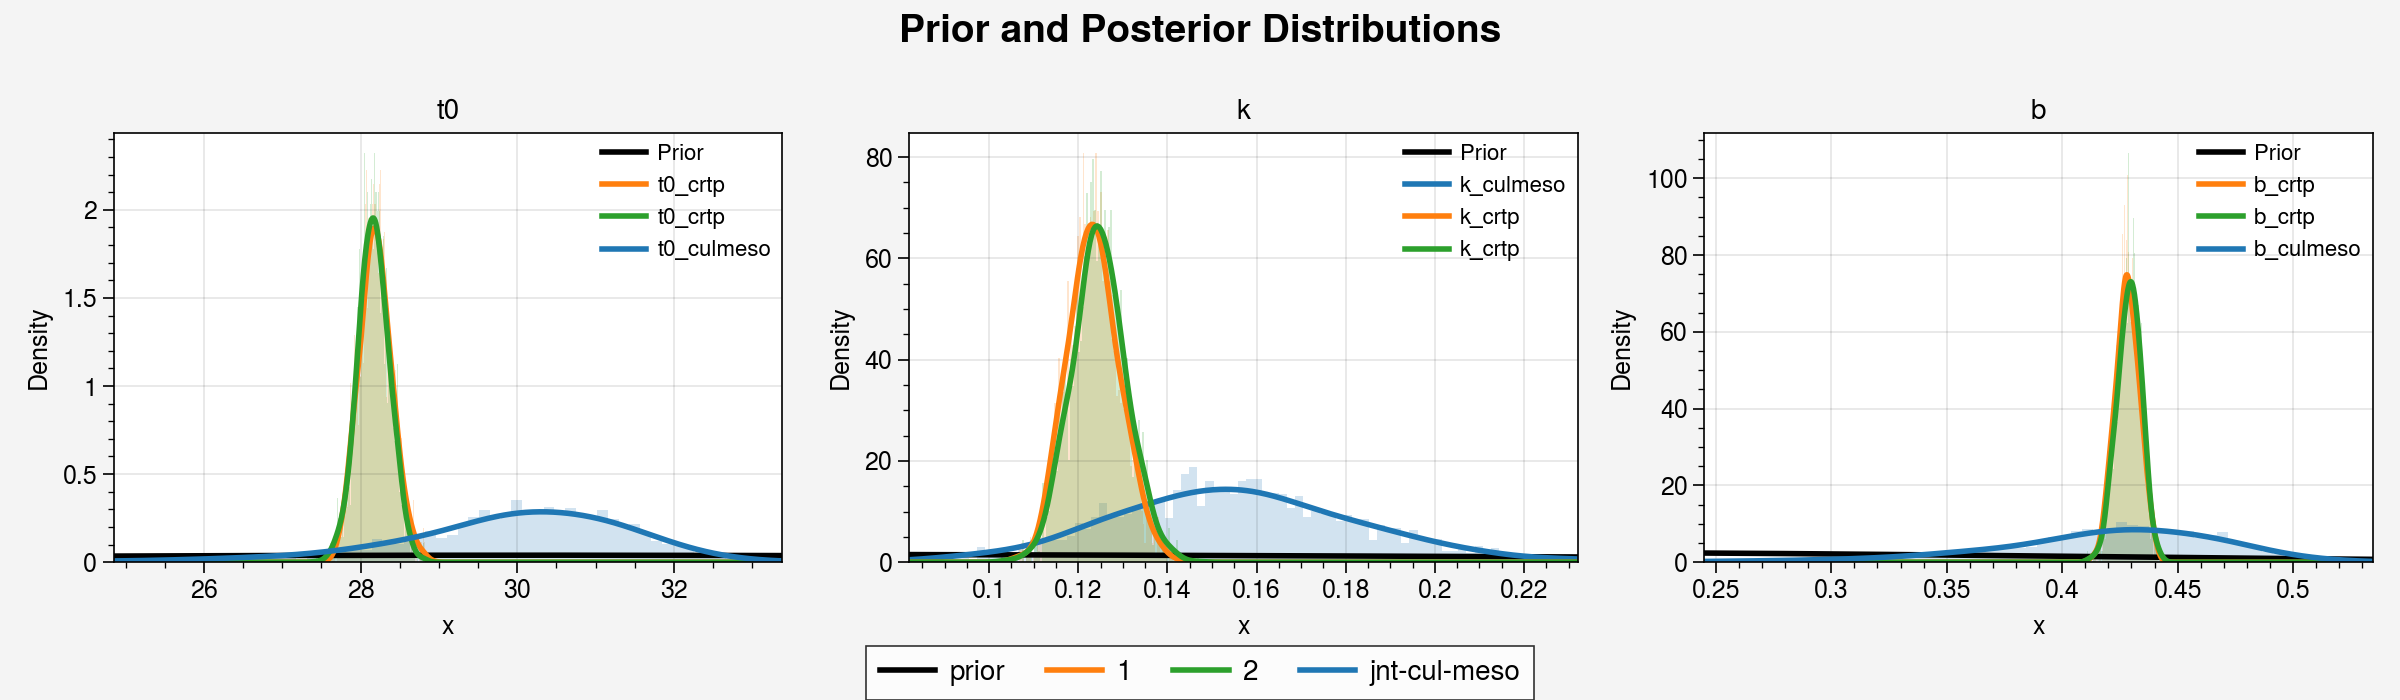

In [21]:
priors = jnt_cul_meso_post_ds.attrs['priors']
dv.plot_prior_distributions(priors,
                            posterior_datasets=[
                                jnt_cul_meso_post_ds,
                                hier_crtp_univ_prior_logmixture_post_ds,
                                hier_crtp_univ_prior_approx_post_ds
                                ],
                            labels=[
                                'prior',
                                '1',
                                '2',
                                'jnt-cul-meso',
                                ],
                            # focus_on_posterior=False
                            )

## jnt_cul_meso_crtp

In [22]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_crtp_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_crtp_post_ds, filename=stan_file_name)

##########################################################
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_sst_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_crtp_sst_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_crtp_sst_post_ds, filename=stan_file_name+'_sst')

##########################################################
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df_low23),
    "t_crtp": t_crtp_low23,
    "scaledRI_crtp": scaledRI_crtp_low23,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_low23_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_crtp_low23_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_crtp_low23_post_ds, filename=stan_file_name+'_low23')

##########################################################
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df_low23),
    "t_crtp": sst_crtp_low23,
    "scaledRI_crtp": scaledRI_crtp_low23,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_sst_low23_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_crtp_sst_low23_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_crtp_sst_low23_post_ds, filename=stan_file_name+'_sst_low23')

09:46:01 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp
09:46:10 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp
09:46:10 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

09:46:19 - cmdstanpy - INFO - CmdStan done processing.
09:46:19 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.545, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 40, column 2 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 40, column 2 to column 66)
Exception: beta_lpdf: Random variable is 1.70106, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: be


Sampling completed in 1.2 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/jnt_cul_meso_crtprvx7ecu3/jnt_cul_meso_crtp-20250531094618_1.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_crtprvx7ecu3/jnt_cul_meso_crtp-20250531094618_2.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_crtprvx7ecu3/jnt_cul_meso_crtp-20250531094618_3.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_crtprvx7ecu3/jnt_cul_meso_crtp-20250531094618_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.



<xarray.Dataset>
Dimensions:              (draw: 2000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
Data variables:
    t0_culmesocore       (draw) float64 27.72 27.74 28.43 ... 27.77 27.91 28.09
    k_culmesocore        (draw) float64 0.1223 0.1219 0.116 ... 0.1272 0.1199
    b_culmesocore        (draw) float64 0.4369 0.4346 0.436 ... 0.4353 0.4425
    sigma_scaledRI_cul   (draw) float64 0.08985 0.09292 ... 0.0927 0.08932
    sigma_scaledRI_meso  (draw) float64 0.05097 0.04649 ... 0.07148 0.06199
    sigma_scaledRI_crtp  (draw) float64 0.05774 0.0565 ... 0.05773 0.0574
Attributes: (12/24)
    stan_model_name:     jnt_cul_meso_crtp.stan
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-05-31T09:46:19.976792
    run_duration (sec):  1.17
    N_cul:               79
    ...                  ...
    scaledRI_crtp_mean:  0.5587046676180477
    scaledRI_crtp_std:   0.1160232103122677
    scaledRI_crtp_min:   0.31454487475
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   723
    priors:              ['t0_culmesocore: normal(20, 20) T[-4, ]', 'k_culmes...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst_low23.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst_low23.nc')

## jnt_cul_meso_hier_crtp

In [23]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp'
jnt_cul_meso_hier_crtp_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_hier_crtp_post_ds)
# Save posteriors
save_posterior(jnt_cul_meso_hier_crtp_post_ds, filename=stan_file_name)

09:46:20 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
09:46:29 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
09:46:29 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:46:37 - cmdstanpy - INFO - CmdStan done processing.
09:46:37 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 56, column 2 to column 61)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 56, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 56, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 56, column 2 to column 61)
Exception: normal_lpdf: S


Sampling completed in 17.8 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtpm7g49t88/jnt_cul_meso_hier_crtp-20250531094629_1.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtpm7g49t88/jnt_cul_meso_hier_crtp-20250531094629_2.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtpm7g49t88/jnt_cul_meso_hier_crtp-20250531094629_3.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtpm7g49t88/jnt_cul_meso_hier_crtp-20250531094629_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
12 of 2000 (0.60%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat v

<xarray.Dataset>
Dimensions:              (draw: 2000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
Data variables:
    t0_culmeso           (draw) float64 27.85 28.7 29.61 ... 28.13 27.6 28.21
    k_culmeso            (draw) float64 0.109 0.1593 0.1527 ... 0.1369 0.1225
    b_culmeso            (draw) float64 0.3545 0.429 0.4058 ... 0.3405 0.3342
    t0_crtp              (draw) float64 28.09 28.29 28.33 ... 28.01 27.81 28.07
    k_crtp               (draw) float64 0.1237 0.1241 0.1285 ... 0.1222 0.1231
    b_crtp               (draw) float64 0.4268 0.4308 0.4317 ... 0.4244 0.4239
    sigma_t0_culmeso     (draw) float64 1.077 0.4058 1.024 ... 0.9549 0.4668
    sigma_k_culmeso      (draw) float64 0.2501 0.5586 0.6035 ... 0.8647 0.9166
    sigma_b_culmeso      (draw) float64 0.3844 0.04415 0.02799 ... 0.1566 0.1172
    sigma_scaledRI_cul   (draw) float64 0.09462 0.07945 ... 0.06606 0.0715
    sigma_scaledRI_meso  (draw) float64 0.1014 0.07644 0.084 ... 0.1219 0.13
    sigma_scaledRI_crtp  (draw) float64 0.05743 0.06236 ... 0.06041 0.0592
Attributes: (12/24)
    stan_model_name:     jnt_cul_meso_hier_crtp.stan
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-05-31T09:46:37.898904
    run_duration (sec):  17.8
    N_cul:               79
    ...                  ...
    scaledRI_crtp_mean:  0.5557237381745532
    scaledRI_crtp_std:   0.11105198051279462
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1402
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp.nc')

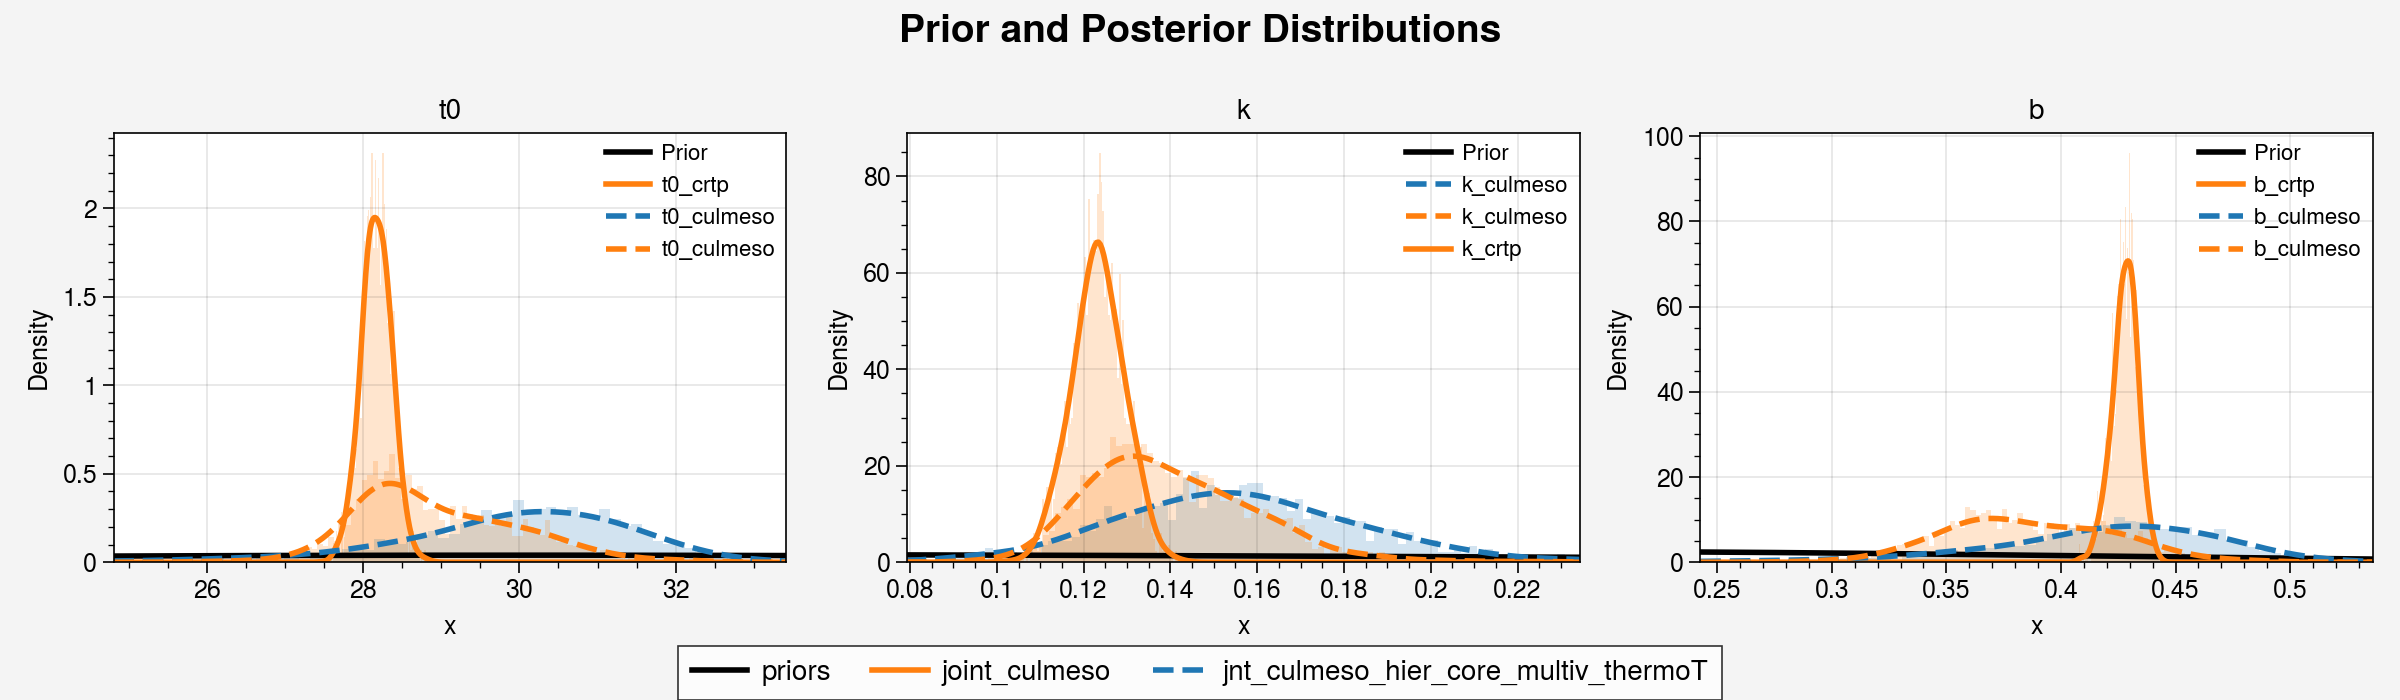

In [24]:
priors = jnt_cul_meso_post_ds.attrs['priors']

fig, axes = dv.plot_prior_distributions(
                priors,
                posterior_datasets=[
                    jnt_cul_meso_post_ds,
                    jnt_cul_meso_hier_crtp_post_ds
                    ],
                labels=['priors',
                        'joint_culmeso',
                        'jnt_culmeso_hier_core_multiv_thermoT'
                        ],
                # focus_on_posterior=False,
                use_linestyle_by_param=True,
                # suffix_include=["_culmeso"]
                )

In [25]:
# ### cul + meso + coretop
# data = {
#     "N_cul": len(culture_data_full),
#     "t_cul": t_cul,
#     "scaledRI_cul": scaledRI_cul,
#     "N_meso": len(meso_data_full),
#     "t_meso": t_meso,
#     "scaledRI_meso": scaledRI_meso,
#     "N_crtp": len(coretop_df),
#     "t_crtp": sst_crtp,
#     "scaledRI_crtp": scaledRI_crtp,

# }
# stan_file_name = 'jnt_cul_meso_hier_crtp'
# jnt_cul_meso_hier_crtp_sst_post_ds, diag = get_posterior(data, stan_file_name)
# display(jnt_cul_meso_hier_crtp_sst_post_ds)

# # Save posteriors
# save_posterior(jnt_cul_meso_hier_crtp_sst_post_ds, filename=stan_file_name+'_sst')

In [26]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    # "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_multiv_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_hier_crtp_multiv_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_hier_crtp_multiv_post_ds, filename=stan_file_name)

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    # "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_sst_multiv_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_hier_crtp_sst_multiv_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_post_ds, filename=stan_file_name+'_sst')

09:46:39 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
09:46:48 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
09:46:48 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

09:47:15 - cmdstanpy - INFO - CmdStan done processing.
09:47:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)


Sampling completed in 16.5 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivwd0e2jnj/jnt_cul_meso_hier_crtp_multiv-20250531094658_1.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivwd0e2jnj/jnt_cul_meso_hier_crtp_multiv-20250531094658_2.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivwd0e2jnj/jnt_cul_meso_hier_crtp_multiv-20250531094658_3.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivwd0e2jnj/jnt_cul_meso_hier_crtp_multiv-20250531094658_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
11 of 2000 (0.55%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfact

<xarray.Dataset>
Dimensions:                 (draw: 2000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 1995 1996 1997 1998 1999
Data variables: (12/14)
    t0_culmeso              (draw) float64 28.72 30.33 29.0 ... 29.09 28.37
    k_culmeso               (draw) float64 0.1335 0.1396 ... 0.1302 0.1374
    b_culmeso               (draw) float64 0.3711 0.4245 0.391 ... 0.3944 0.373
    t0_crtp                 (draw) float64 29.13 30.17 29.17 ... 29.48 29.69
    k_crtp                  (draw) float64 0.1065 0.1025 ... 0.1162 0.09229
    b_crtp                  (draw) float64 0.4158 0.4209 0.42 ... 0.4281 0.4039
    ...                      ...
    sigma_t0_culmeso        (draw) float64 1.101 0.1382 0.3292 ... 0.7541 1.279
    sigma_k_culmeso         (draw) float64 0.3106 0.03464 ... 1.025 0.1018
    sigma_b_culmeso         (draw) float64 0.06797 0.05619 ... 0.6374 0.2462
    sigma_scaledRI_cul      (draw) float64 0.08156 0.06921 ... 0.0734 0.07833
    sigma_scaledRI_meso     (draw) float64 0.1015 0.09224 ... 0.09352 0.1035
    sigma_scaledRI_crtp     (draw) float64 0.05996 0.06245 ... 0.06185 0.06144
Attributes: (12/24)
    stan_model_name:     jnt_cul_meso_hier_crtp_multiv.stan
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-05-31T09:47:15.165220
    run_duration (sec):  16.53
    N_cul:               79
    ...                  ...
    scaledRI_crtp_mean:  0.5557237381745532
    scaledRI_crtp_std:   0.11105198051279462
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1402
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst.nc')

In [27]:
jnt_cul_meso_hier_crtp_multiv_post_ds

<xarray.Dataset>
Dimensions:                 (draw: 2000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 1995 1996 1997 1998 1999
Data variables: (12/14)
    t0_culmeso              (draw) float64 28.83 28.43 29.19 ... 29.72 30.57
    k_culmeso               (draw) float64 0.1355 0.1697 0.1567 ... 0.1476 0.171
    b_culmeso               (draw) float64 0.4035 0.4067 ... 0.3799 0.4127
    t0_crtp                 (draw) float64 28.07 28.45 28.24 ... 28.09 28.34
    k_crtp                  (draw) float64 0.137 0.1202 0.1259 ... 0.1118 0.1264
    b_crtp                  (draw) float64 0.4381 0.4288 ... 0.4179 0.4292
    ...                      ...
    sigma_t0_culmeso        (draw) float64 2.42 0.5391 1.431 ... 2.003 3.382
    sigma_k_culmeso         (draw) float64 0.7403 0.1407 ... 0.05185 0.1099
    sigma_b_culmeso         (draw) float64 0.02512 0.1054 ... 0.01983 0.2107
    sigma_scaledRI_cul      (draw) float64 0.07304 0.08286 ... 0.08353 0.08509
    sigma_scaledRI_meso     (draw) float64 0.07362 0.1103 ... 0.1031 0.09503
    sigma_scaledRI_crtp     (draw) float64 0.05856 0.0575 ... 0.05898 0.05761
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_hier_crtp_multiv.stan
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-05-31T09:46:58.621822
    run_duration (sec):  19.38
    N_cul:               79
    ...                  ...
    scaledRI_crtp_std:   0.11105198051279462
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1402
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...
    filename:            jnt_cul_meso_hier_crtp_multiv

In [28]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_multiv_g23r_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds, filename=stan_file_name+'_g23r')

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds, diag = get_posterior(data, stan_file_name)
display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds, filename=stan_file_name+'_g23r_sst')

09:47:15 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

09:47:40 - cmdstanpy - INFO - CmdStan done processing.
09:47:40 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 93, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63


Sampling completed in 11.4 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivmia5vvsz/jnt_cul_meso_hier_crtp_multiv-20250531094728_1.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivmia5vvsz/jnt_cul_meso_hier_crtp_multiv-20250531094728_2.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivmia5vvsz/jnt_cul_meso_hier_crtp_multiv-20250531094728_3.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivmia5vvsz/jnt_cul_meso_hier_crtp_multiv-20250531094728_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
12 of 2000 (0.60%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfact

<xarray.Dataset>
Dimensions:                 (draw: 2000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 1995 1996 1997 1998 1999
Data variables: (12/14)
    t0_culmeso              (draw) float64 27.27 27.68 27.47 ... 29.96 29.5
    k_culmeso               (draw) float64 0.1096 0.1079 ... 0.1613 0.1941
    b_culmeso               (draw) float64 0.324 0.3368 0.3115 ... 0.4356 0.4182
    t0_crtp                 (draw) float64 27.25 27.78 27.72 ... 27.08 27.85
    k_crtp                  (draw) float64 0.09688 0.1007 ... 0.1024 0.1084
    b_crtp                  (draw) float64 0.4299 0.4386 ... 0.4339 0.4469
    ...                      ...
    sigma_t0_culmeso        (draw) float64 0.05302 0.2144 0.9714 ... 6.967 1.05
    sigma_k_culmeso         (draw) float64 5.37 0.05077 ... 0.6251 0.1004
    sigma_b_culmeso         (draw) float64 0.1019 0.3459 ... 0.04946 0.1267
    sigma_scaledRI_cul      (draw) float64 0.09343 0.08052 ... 0.07641 0.07198
    sigma_scaledRI_meso     (draw) float64 0.1132 0.07147 ... 0.1073 0.09969
    sigma_scaledRI_crtp     (draw) float64 0.05604 0.05772 ... 0.05627 0.05757
Attributes: (12/30)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv.stan
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-05-31T09:47:40.254825
    run_duration (sec):     11.38
    N_cul:                  79
    ...                     ...
    gdgt23ratio_crtp_std:   3.4678668194270457
    gdgt23ratio_crtp_min:   0.7564253358305837
    gdgt23ratio_crtp_max:   35.072441830778935
    gdgt23ratio_crtp_len:   1402
    use_gdgt23ratio:        1
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_g23r_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_g23r_sst.nc')

In [50]:
no3_cutoff_values = [0.1, 0.5, 1, 1.5, 2, 2.5, 5, 10, 100]
for no3_cutoff in no3_cutoff_values:
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(coretop_df),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        # "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds, diag = get_posterior(data, stan_file_name)
    display(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds, filename=stan_file_name+f'_no3_{no3_cutoff}')

    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(coretop_df),
        "t_crtp": sst_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        # "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds, diag = get_posterior(data, stan_file_name)
    display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds, filename=stan_file_name+f'_no3_{no3_cutoff}_sst')

14:13:19 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
14:13:28 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
14:13:28 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

14:14:57 - cmdstanpy - INFO - CmdStan done processing.
14:14:57 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 71, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 94, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 63


Sampling completed in 5.8 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivf81s991u/jnt_cul_meso_hier_crtp_multiv-20250601141452_1.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivf81s991u/jnt_cul_meso_hier_crtp_multiv-20250601141452_2.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivf81s991u/jnt_cul_meso_hier_crtp_multiv-20250601141452_3.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivf81s991u/jnt_cul_meso_hier_crtp_multiv-20250601141452_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
116 of 2000 (5.80%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfact

<xarray.Dataset>
Dimensions:                 (draw: 2000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 1995 1996 1997 1998 1999
Data variables: (12/14)
    t0_culmeso              (draw) float64 31.45 31.01 30.28 ... 31.35 31.34
    k_culmeso               (draw) float64 0.1872 0.154 0.1697 ... 0.183 0.1548
    b_culmeso               (draw) float64 0.4704 0.4297 0.439 ... 0.4738 0.4438
    t0_crtp                 (draw) float64 32.18 30.85 31.51 ... 31.76 31.58
    k_crtp                  (draw) float64 0.1175 0.14 0.1227 ... 0.1257 0.1083
    b_crtp                  (draw) float64 0.4622 0.4662 0.4612 ... 0.466 0.4459
    ...                      ...
    sigma_t0_culmeso        (draw) float64 1.407 0.3332 2.33 ... 1.819 0.2689
    sigma_k_culmeso         (draw) float64 0.04514 0.6935 ... 0.0347 3.349
    sigma_b_culmeso         (draw) float64 0.009761 0.7332 ... 0.0111 0.008839
    sigma_scaledRI_cul      (draw) float64 0.07989 0.07354 ... 0.07157 0.07888
    sigma_scaledRI_meso     (draw) float64 0.1154 0.08327 ... 0.07901 0.157
    sigma_scaledRI_crtp     (draw) float64 0.05956 0.05764 ... 0.05912 0.05754
Attributes: (12/30)
    stan_model_name:     jnt_cul_meso_hier_crtp_multiv.stan
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-01T14:14:58.005213
    run_duration (sec):  5.83
    N_cul:               79
    ...                  ...
    no3_crtp_std:        8.082328831667393
    no3_crtp_min:        0.0002862779365386814
    no3_crtp_max:        33.803863525390625
    no3_crtp_len:        1402
    use_no3:             1
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_no3_100_sst.nc


In [49]:
no3_cutoff_values = [0.1, 0.5, 1, 1.5, 2, 2.5, 5, 10, 100]
for no3_cutoff in no3_cutoff_values:
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(coretop_df),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds, diag = get_posterior(data, stan_file_name)
    display(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds, filename=stan_file_name+f'_g23r_no3_{no3_cutoff}')

    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(coretop_df),
        "t_crtp": sst_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds, diag = get_posterior(data, stan_file_name)
    display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds, filename=stan_file_name+f'_g23r_no3_{no3_cutoff}_sst')

15:43:18 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

15:48:21 - cmdstanpy - INFO - CmdStan done processing.
15:48:21 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 93, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63


Sampling completed in 14.6 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivhukrkzqg/jnt_cul_meso_hier_crtp_multiv-20250531154806_1.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivhukrkzqg/jnt_cul_meso_hier_crtp_multiv-20250531154806_2.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivhukrkzqg/jnt_cul_meso_hier_crtp_multiv-20250531154806_3.csv, /tmp/tmpgg__4b7s/jnt_cul_meso_hier_crtp_multivhukrkzqg/jnt_cul_meso_hier_crtp_multiv-20250531154806_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
6 of 2000 (0.30%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfacto

<xarray.Dataset>
Dimensions:                 (draw: 2000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 1995 1996 1997 1998 1999
Data variables: (12/14)
    t0_culmeso              (draw) float64 29.57 29.23 31.11 ... 29.9 30.37 30.0
    k_culmeso               (draw) float64 0.1208 0.1618 ... 0.1305 0.1392
    b_culmeso               (draw) float64 0.3982 0.4038 ... 0.4081 0.4103
    t0_crtp                 (draw) float64 29.72 29.75 29.68 ... 29.73 29.66
    k_crtp                  (draw) float64 0.1057 0.1104 ... 0.1155 0.1045
    b_crtp                  (draw) float64 0.4728 0.4686 ... 0.4729 0.4646
    ...                      ...
    sigma_t0_culmeso        (draw) float64 0.9948 0.6141 0.9033 ... 0.3183 2.197
    sigma_k_culmeso         (draw) float64 0.02895 0.2667 ... 0.01381 0.04741
    sigma_b_culmeso         (draw) float64 0.1589 0.3245 0.48 ... 0.6725 0.04838
    sigma_scaledRI_cul      (draw) float64 0.07637 0.0731 ... 0.08439 0.07173
    sigma_scaledRI_meso     (draw) float64 0.07095 0.0902 ... 0.08544 0.102
    sigma_scaledRI_crtp     (draw) float64 0.05605 0.05657 ... 0.05505 0.05548
Attributes: (12/36)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv.stan
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-05-31T15:48:21.292217
    run_duration (sec):     14.58
    N_cul:                  79
    ...                     ...
    no3_crtp_std:           8.082328831667393
    no3_crtp_min:           0.0002862779365386814
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_g23r_no3_100_sst.nc


In [30]:
jnt_cul_meso_post_ds

<xarray.Dataset>
Dimensions:                 (draw: 2000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 1995 1996 1997 1998 1999
Data variables:
    t0_culmeso              (draw) float64 30.56 31.43 29.68 ... 28.75 29.81
    k_culmeso               (draw) float64 0.1614 0.1675 0.1503 ... 0.1491 0.142
    b_culmeso               (draw) float64 0.4654 0.4341 0.3848 ... 0.38 0.4075
    sigma_scaledRI_cul      (draw) float64 0.07666 0.07933 ... 0.08103 0.0694
    sigma_scaledRI_meso     (draw) float64 0.1179 0.1144 0.1013 ... 0.1268 0.131
    sigma_scaledRI_culmeso  (draw) float64 0.08667 0.08764 ... 0.09224 0.08564
Attributes: (12/19)
    stan_model_name:     jnt_cul_meso.stan
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-05-31T09:44:49.676513
    run_duration (sec):  9.31
    N_cul:               79
    ...                  ...
    scaledRI_meso_std:   0.13845152852523196
    scaledRI_meso_min:   0.4640795035
    scaledRI_meso_max:   0.92620505575
    scaledRI_meso_len:   21
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...
    filename:            jnt_cul_meso

# Posterior plots --- QC

### 1. Joint culture-mesocosm

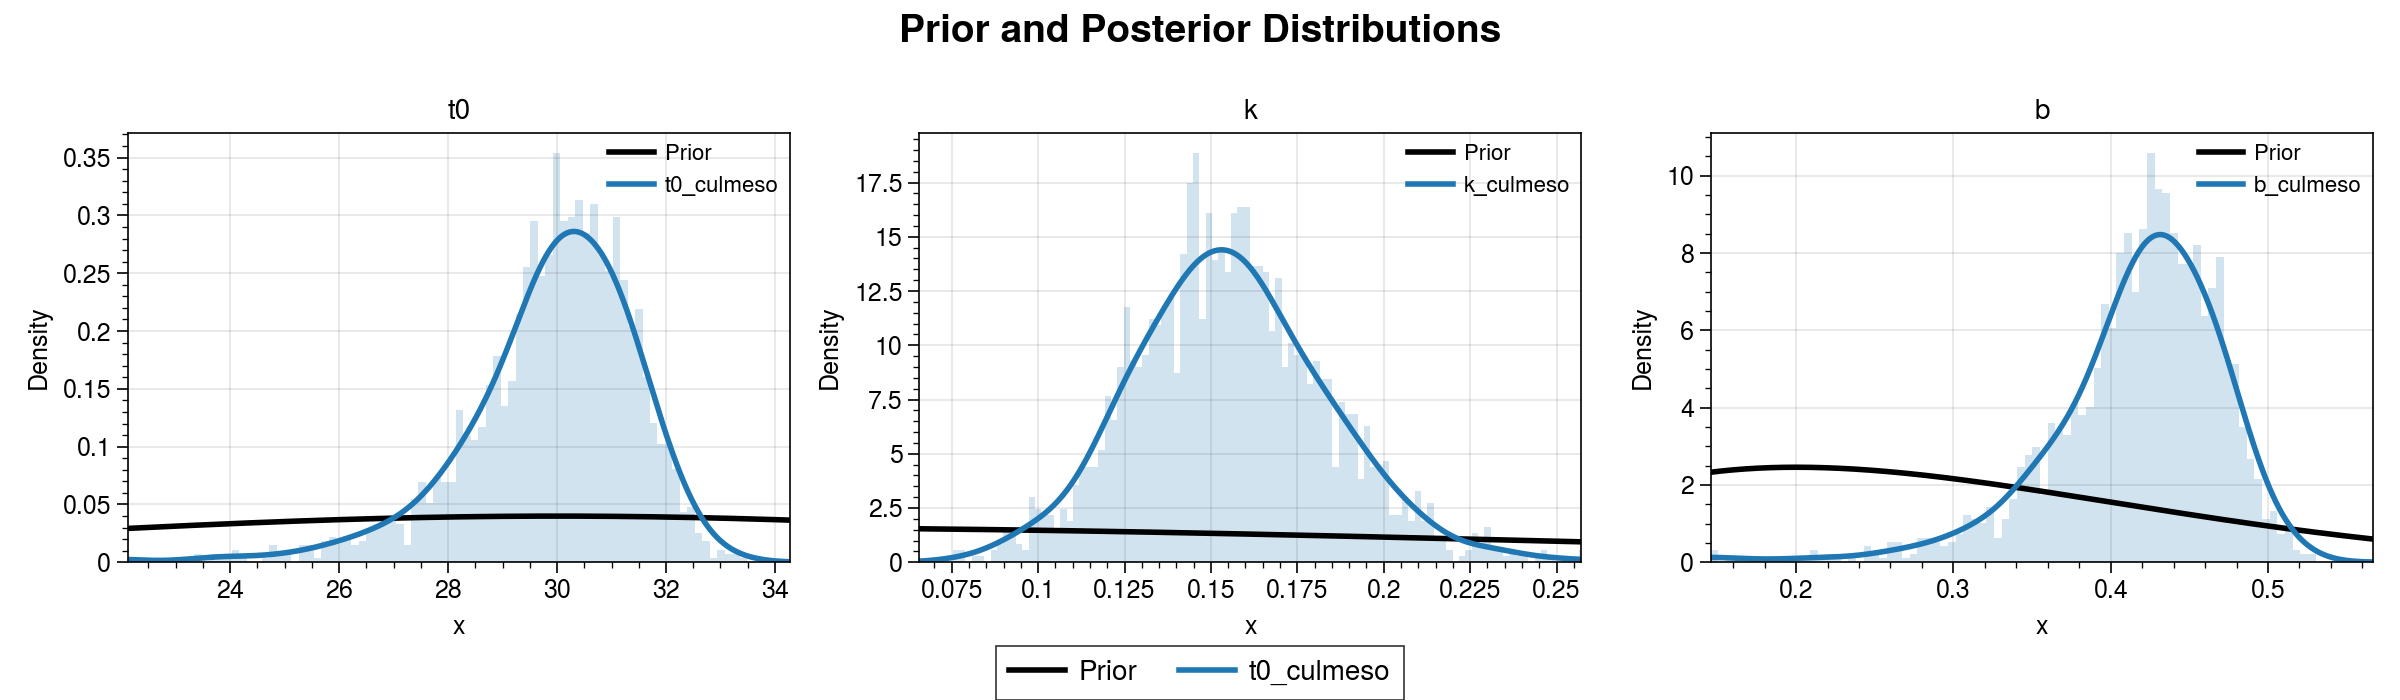

In [31]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[jnt_cul_meso_post_ds]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 2. Joint  culture-mesocosm vs culture-mesocosm-coretop

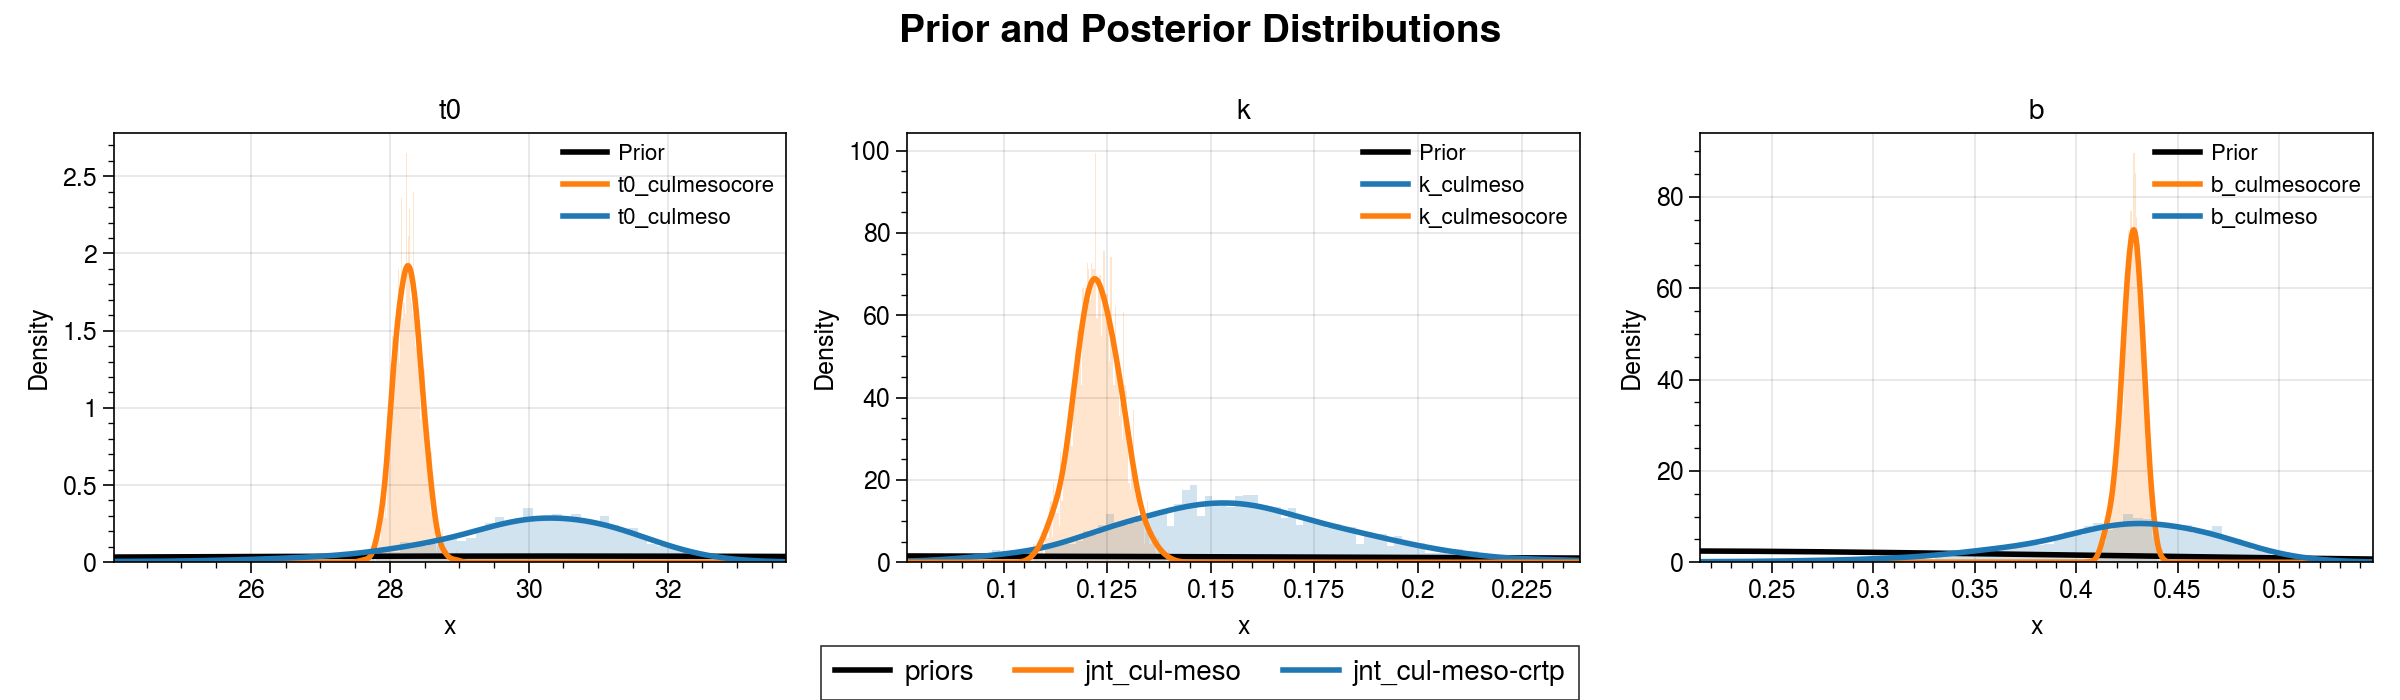

In [32]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        jnt_cul_meso_crtp_post_ds
        ],
    labels=[
        "priors",
        "jnt_cul-meso",
        "jnt_cul-meso-crtp"
        ]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 3. jnt-culture-mesocosm vs jnt-culture-mesocosm-coretop vs jnt-culmeso-hier-crtp

In [33]:
%load_ext autoreload
%autoreload 2


In [34]:
import importlib

import culRIBayesian.dataviz_utils as dv
importlib.reload(dv)

<module 'culRIBayesian.dataviz_utils' from '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/dataviz_utils.py'>

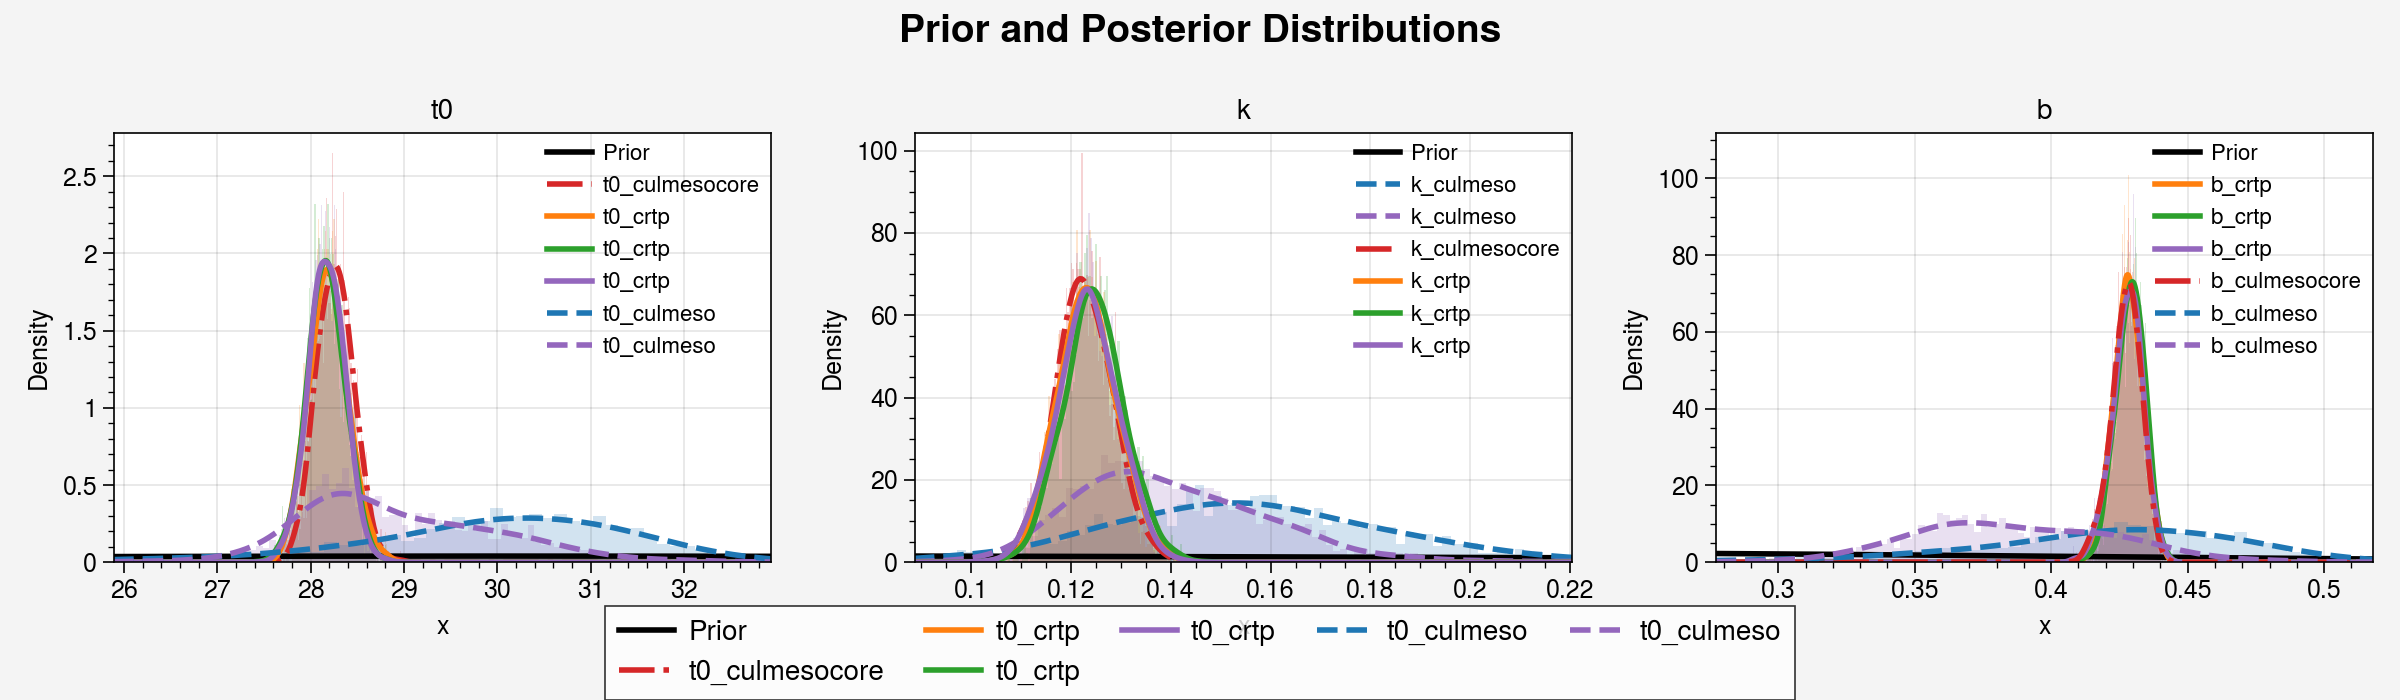

In [36]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_hier_crtp_post_ds
        ],
    # labels=[
    #     "priors",
    #     "jnt-cul-meso",
    #     "jnt-cul-meso-crtp",
    #     "jnt-cul-meso_hier-crtp"
    #     ],
    use_linestyle_by_param=True,
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


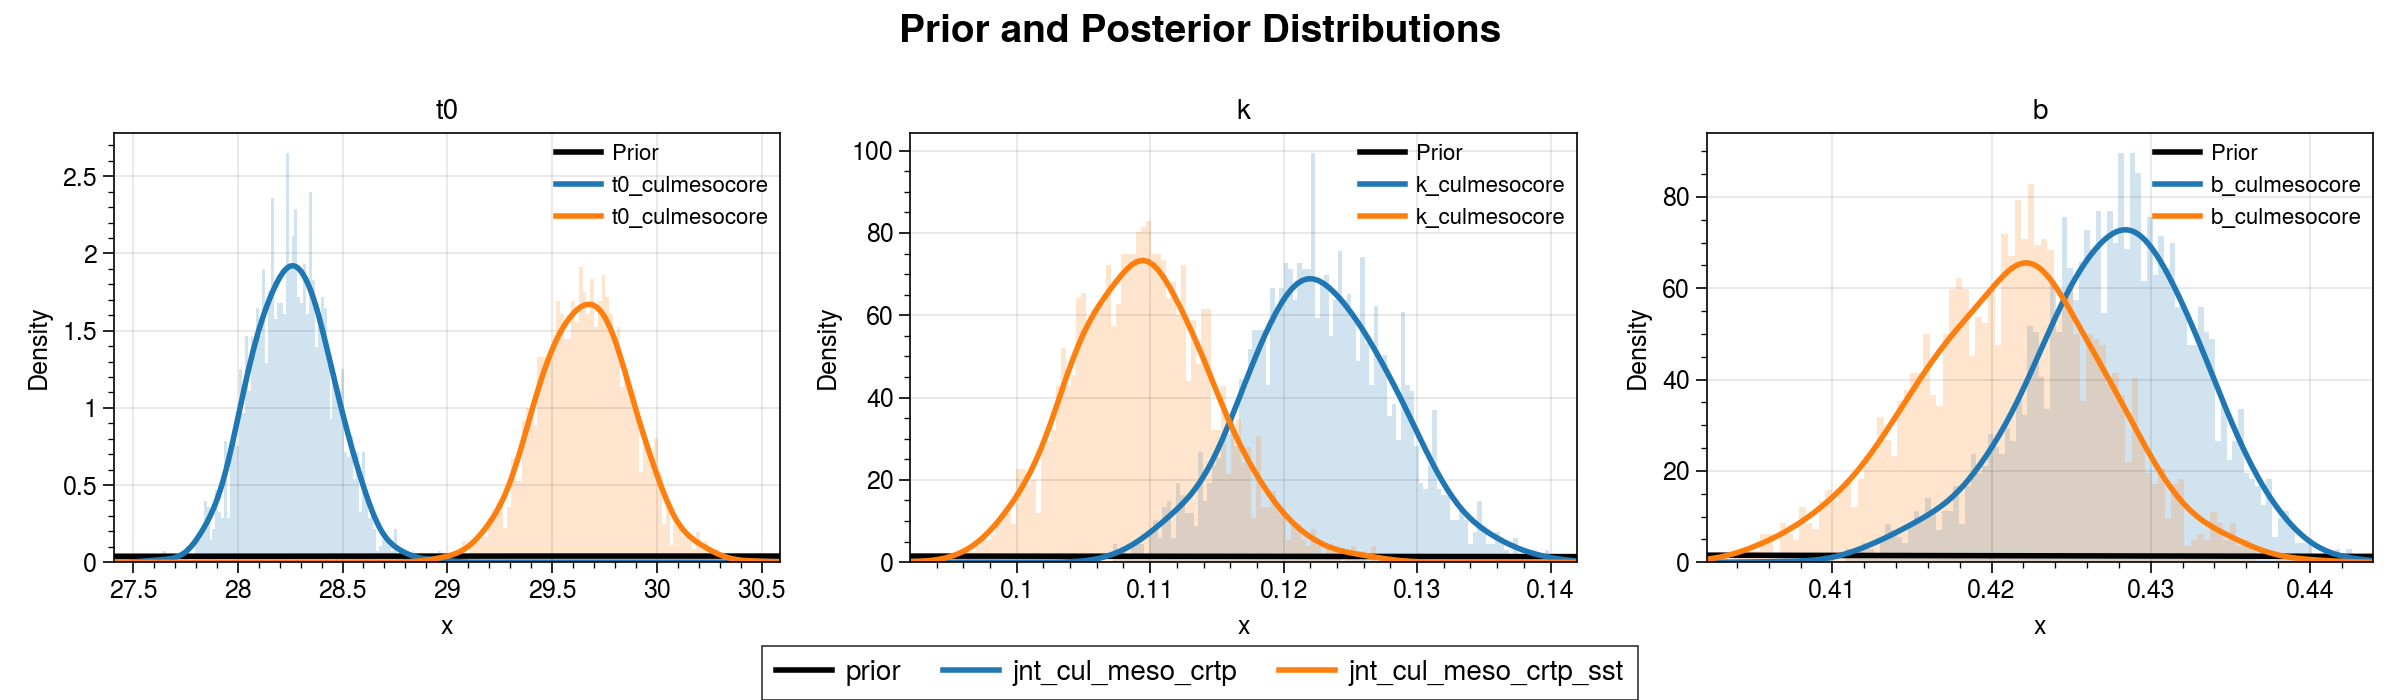

In [37]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_crtp_sst_post_ds
        ],
    labels=[
        "prior",
        "jnt_cul_meso_crtp",
        "jnt_cul_meso_crtp_sst"
        ]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


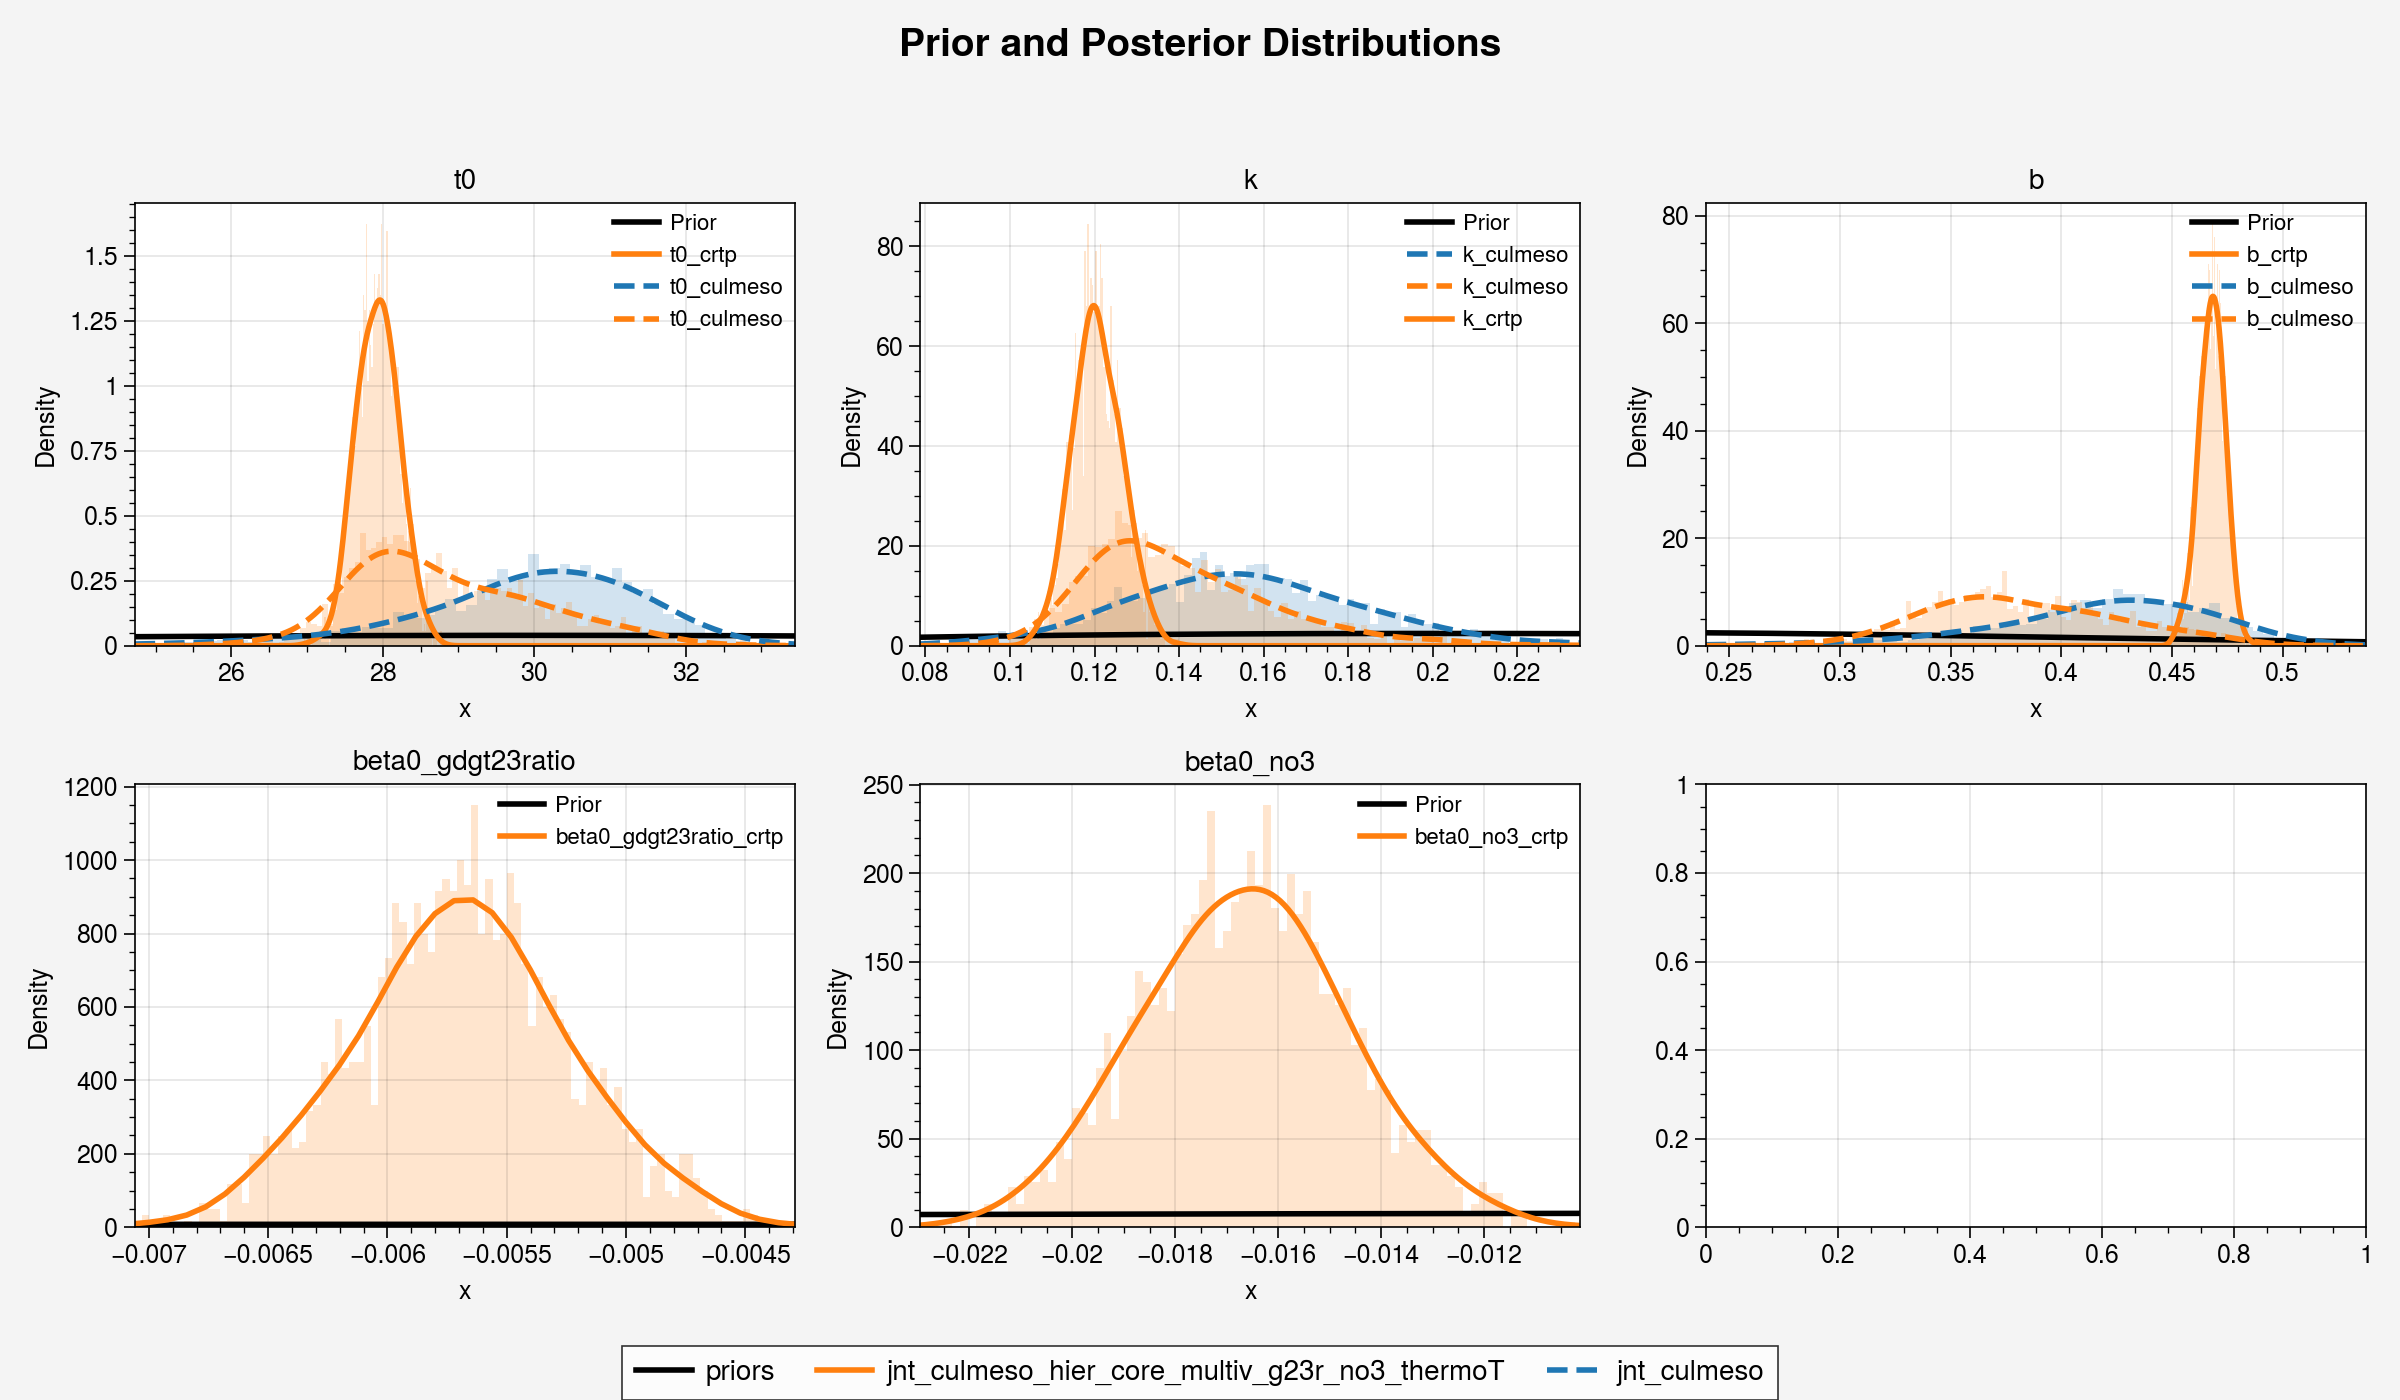

In [43]:
priors = jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds.attrs['priors']

fig, axes = dv.plot_prior_distributions(
                priors,
                posterior_datasets=[
                    jnt_cul_meso_post_ds,
                    # jnt_cul_meso_crtp_post_ds,
                    # jnt_cul_meso_hier_crtp_multiv_post_ds,
                    # jnt_cul_meso_hier_crtp_multiv_g23r_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds,
                    ],
                labels=['priors',
                        # 'jnt_culmesocore',
                        # 'jnt_culmeso_hier_core_multiv_thermoT',
                        # 'jnt_culmeso_hier_core_multiv_g23r_thermoT',
                        'jnt_culmeso_hier_core_multiv_g23r_no3_thermoT',
                        'jnt_culmeso',
                        ],
                # focus_on_posterior=False,
                use_linestyle_by_param=True,
                # suffix_include=["_crtp"]
                )

# axes[0,2].set_xlim(0.4,0.5)

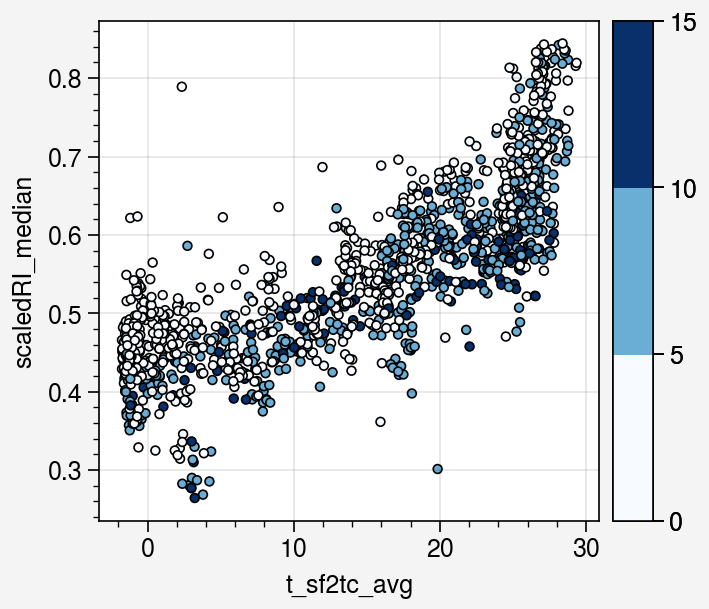

In [39]:
fig,  axs = plot.subplots()

ax = axs[0]
plot_x = coretop_df['t_sf2tc_avg']
plot_y = coretop_df['scaledRI_median']
plot_c = coretop_df['gdgt23ratio_median']
m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
ax.colorbar(m, loc='r')

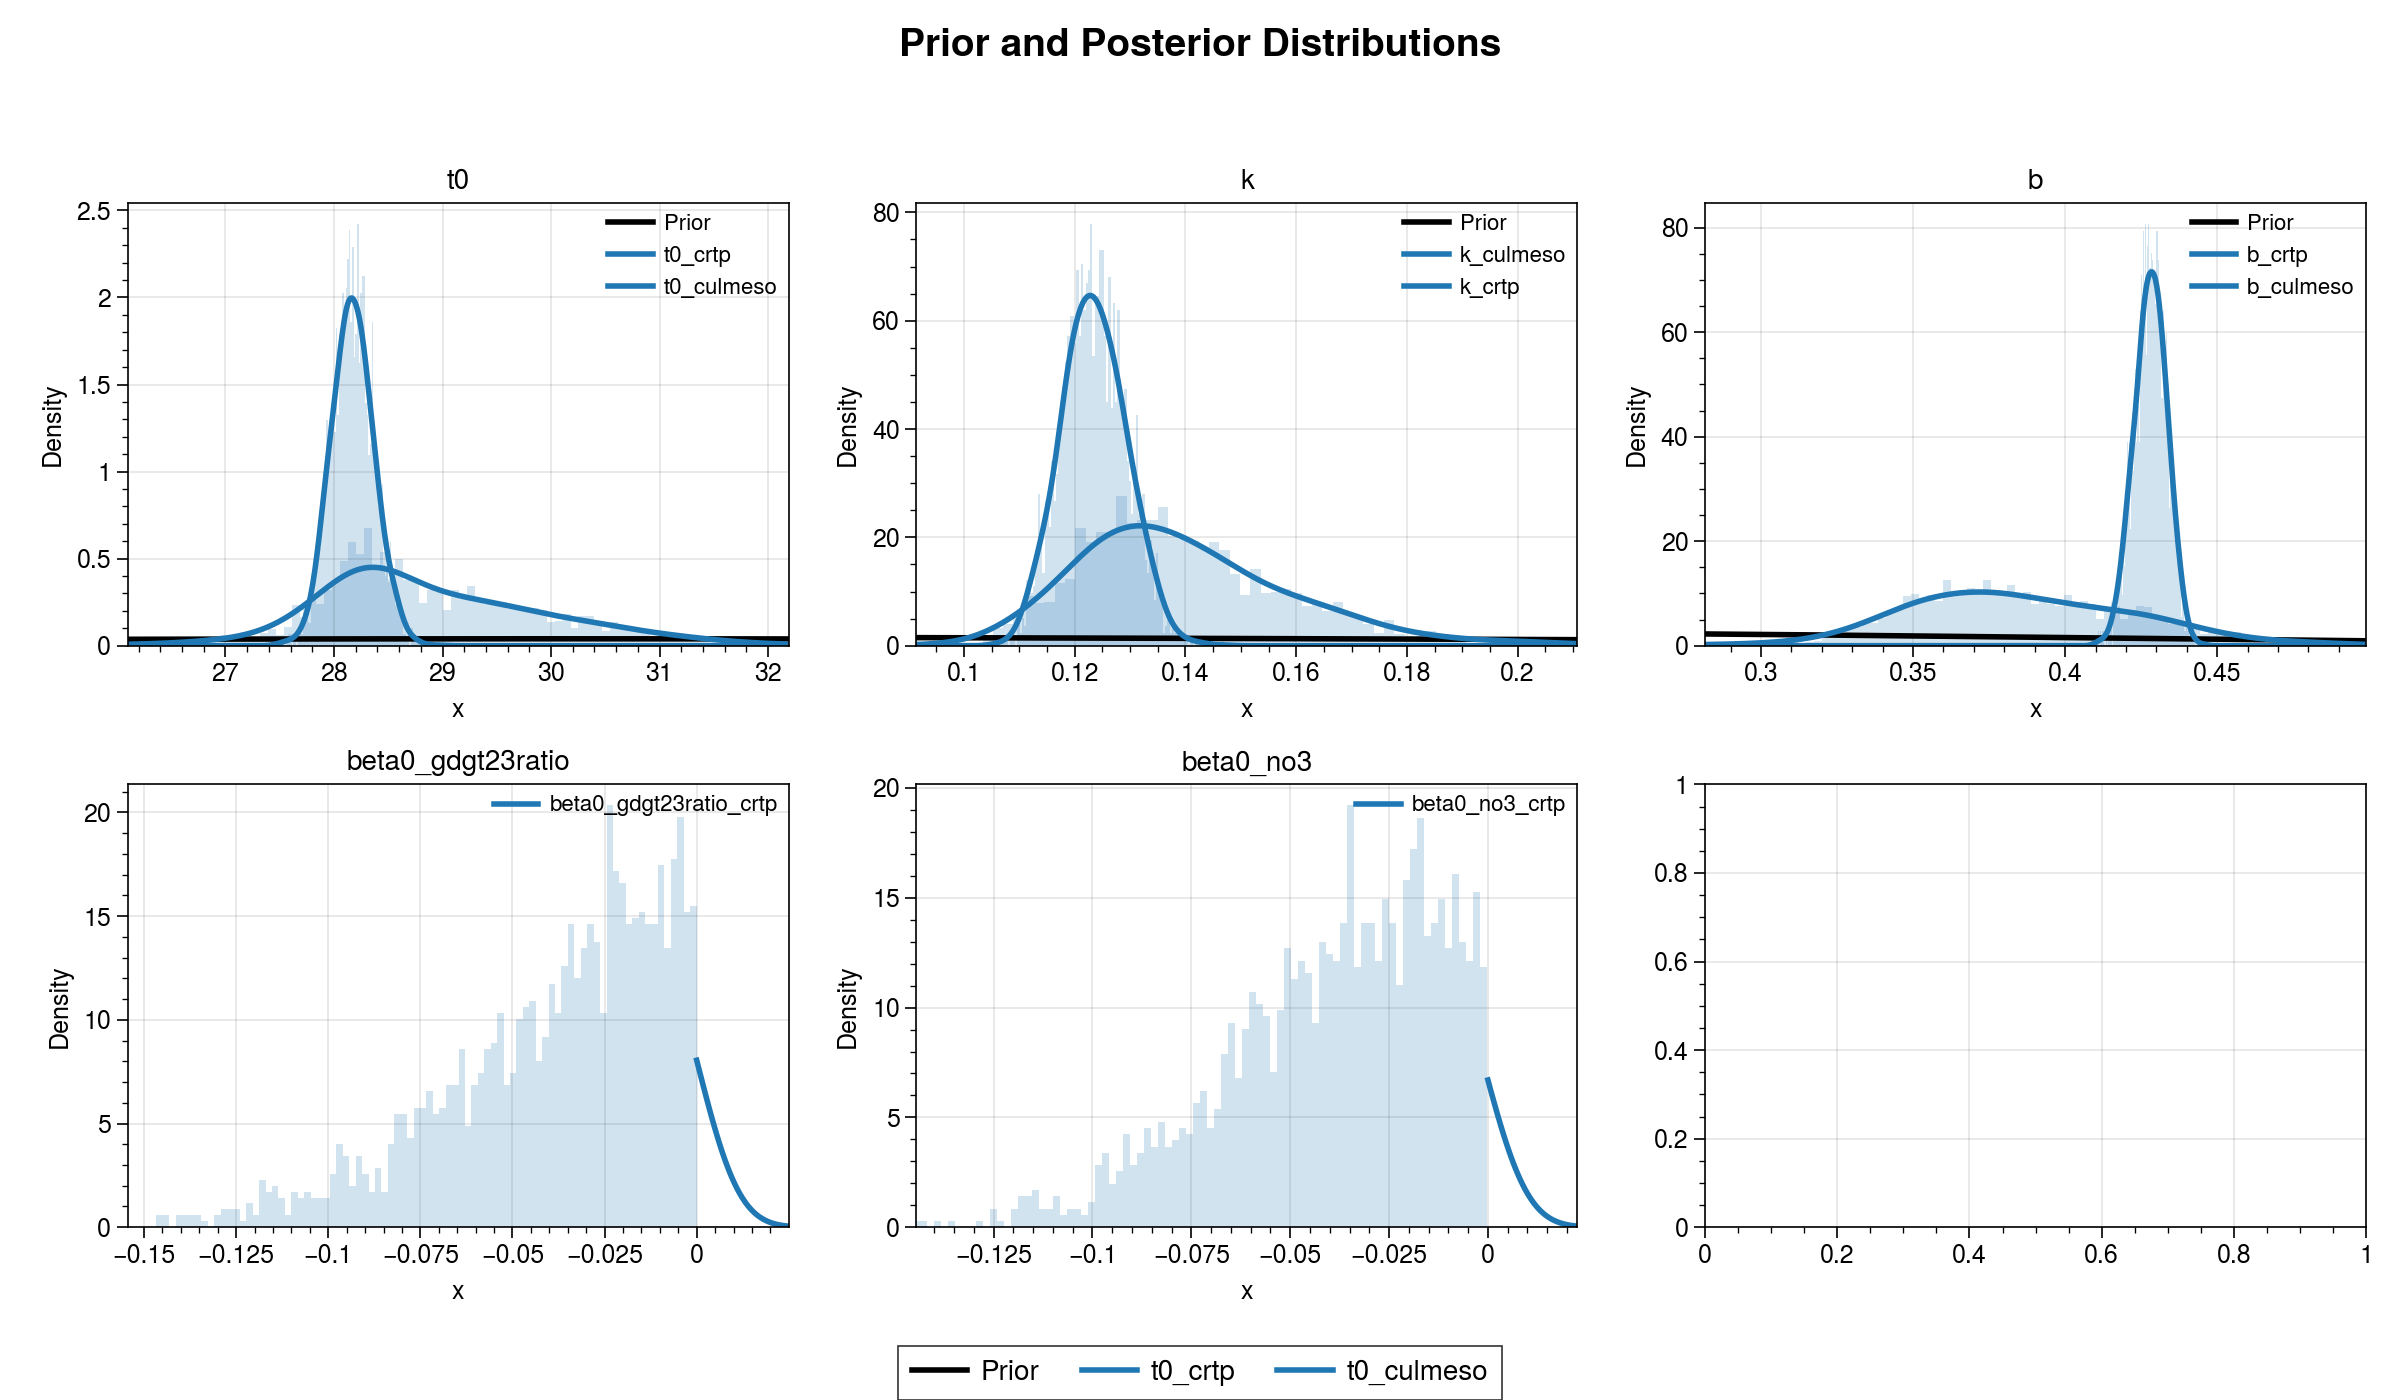

In [40]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[jnt_cul_meso_hier_crtp_multiv_post_ds]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
